K-means Elbow Method Vs Silhouette Score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [3]:
#Import 2nd Dataset, 2019 Flight Delay Info

delays_2019 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2019_Delay_Data\full_data_flightdelay.csv")

delays_2019.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND
0,1,7,0,0800-0859,2,1,25,143,Southwest Airlines Co.,13056,...,8,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
1,1,7,0,0700-0759,7,1,29,191,Delta Air Lines Inc.,13056,...,3,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
2,1,7,0,0600-0659,7,1,27,199,Delta Air Lines Inc.,13056,...,18,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
3,1,7,0,0600-0659,9,1,27,180,Delta Air Lines Inc.,13056,...,2,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
4,1,7,0,0001-0559,7,1,10,182,Spirit Air Lines,13056,...,1,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91


In [4]:
#The target variable for this dataset is "DEP_DEL15" it is a binary 1 if the flight was delayed more than 15 minutes in its departure delay else 0
delays_2019.drop(["DEP_TIME_BLK","DEPARTING_AIRPORT", "PREVIOUS_AIRPORT", "CARRIER_NAME"], axis=1, inplace=True)

target_2019 = delays_2019["DEP_DEL15"]
variables_2019 = delays_2019.drop(["DEP_DEL15"], axis = 1)

scaled_2019 = StandardScaler().set_output(transform="pandas").fit_transform(variables_2019)

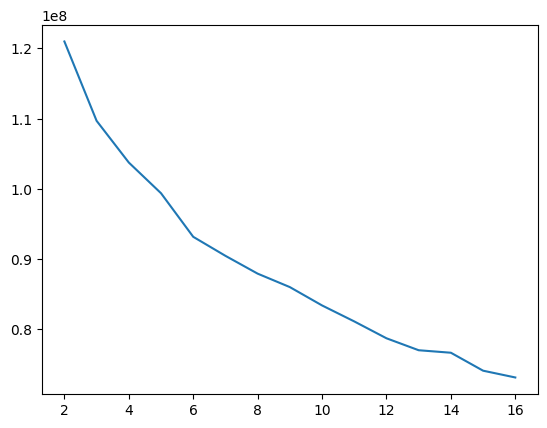

In [4]:
num_clusters = []
inertias = []

for i in range(15):
    km_model = KMeans(n_clusters=i+2).fit(scaled_2019)
    inertias.append(km_model.inertia_)
    num_clusters.append(i+2)

plt.plot(num_clusters,inertias)

I had planned to try an initial fit of K means to examine the Elbow Method before getting more involved with hyperparameters. The shape of the plot of inertia is changing each time it is generated. I expect it has to do with the initial points chosen each time because the model is not maxing out its iterations. I even had an instance where inertia increase from 11 to 12 groups. I am going to try repeatedly running each number of clusters to see if that steadies the plot.

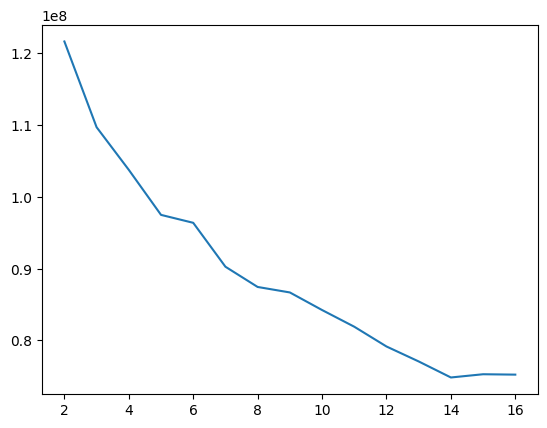

In [5]:
#Example of a different shaped elbow curve
num_clusters = []
inertias_2 = []

for i in range(15):
    km_model = KMeans(n_clusters=i+2).fit(scaled_2019)
    inertias_2.append(km_model.inertia_)
    num_clusters.append(i+2)

plt.plot(num_clusters,inertias_2)

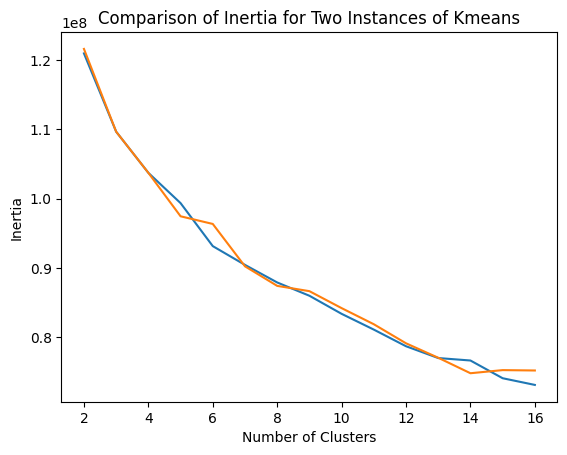

In [8]:
plt.plot(num_clusters, inertias)
plt.plot(num_clusters,inertias_2)
plt.title("Comparison of Inertia for Two Instances of Kmeans")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig("Inertia Comparison.png")

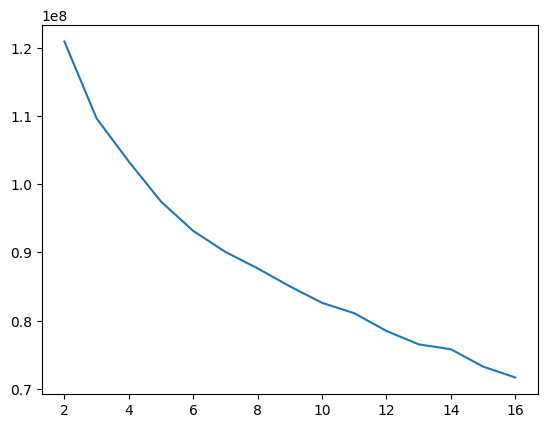

In [26]:
num_clusters = []
inertias = []

for i in range(15):
    best_inertia = 1e15
    for _ in range(10):
        km_model = KMeans(n_clusters=i+2).fit(scaled_2019)
        inertia = km_model.inertia_
        if inertia < best_inertia:
            best_inertia = inertia
    inertias.append(best_inertia)
    num_clusters.append(i+2)

plt.plot(num_clusters,inertias)

That looks more like a normal decreasing inertia curve. I do not see a clear elbow point though. I am going to pivot to Silhouette score first to get an idea of where the best number of groups may be.

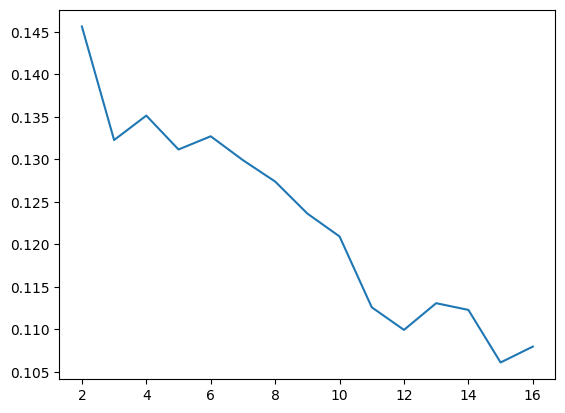

In [31]:
num_clusters = []
silhouettes = []

for i in range(15):
    best_silhouette = 0
    for _ in range(10):
        km_model = KMeans(n_clusters=i+2).fit(scaled_2019)
        labels = km_model.labels_
        score = metrics.silhouette_score(scaled_2019, labels=labels, sample_size=5000, random_state=42)
        if score > best_silhouette:
            best_silhouette = score
    silhouettes.append(best_silhouette)
    num_clusters.append(i+2)

plt.plot(num_clusters,silhouettes)

There are over 6 million samples. Running this without limiting the number of samples used to score the metric took over 400 minutes and had not finished.

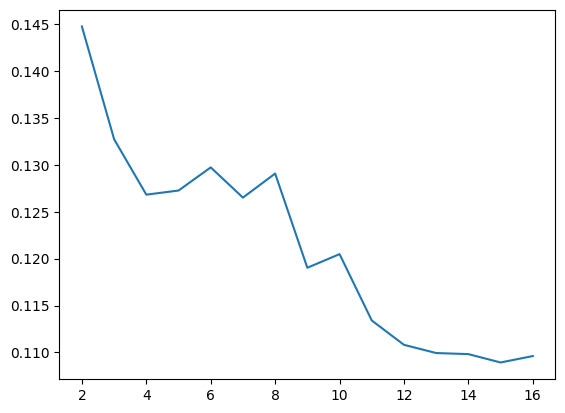

In [9]:
#Increasing sample size
num_clusters = []
silhouettes = []

for i in range(15):
    best_silhouette = 0
    for _ in range(10):
        km_model = KMeans(n_clusters=i+2).fit(scaled_2019)
        labels = km_model.labels_
        score = metrics.silhouette_score(scaled_2019, labels=labels, sample_size=25000, random_state=42)
        if score > best_silhouette:
            best_silhouette = score
    silhouettes.append(best_silhouette)
    num_clusters.append(i+2)

plt.plot(num_clusters,silhouettes)

By a notable margin, the best silhouette score is at 2 clusters

In [5]:
km_model = KMeans(n_clusters=2).fit(scaled_2019)
labels = km_model.labels_
variables_2019['Cluster'] = labels

In [33]:
cluster_0 = variables_2019[variables_2019['Cluster']==0]
cluster_1 = variables_2019[variables_2019['Cluster']==1]
cluster_0.mean() - cluster_1.mean()

MONTH                           -1.723230e-01
DAY_OF_WEEK                      1.633117e-02
DISTANCE_GROUP                   3.276130e-01
SEGMENT_NUMBER                  -1.952718e-01
CONCURRENT_FLIGHTS              -3.843468e+01
NUMBER_OF_SEATS                  2.094727e+00
AIRPORT_FLIGHTS_MONTH           -1.662646e+04
AIRLINE_FLIGHTS_MONTH            1.452800e+02
AIRLINE_AIRPORT_FLIGHTS_MONTH   -5.632427e+03
AVG_MONTHLY_PASS_AIRPORT        -2.009332e+06
AVG_MONTHLY_PASS_AIRLINE        -3.755693e+05
FLT_ATTENDANTS_PER_PASS         -3.929177e-05
GROUND_SERV_PER_PASS            -1.536921e-05
PLANE_AGE                       -1.140725e+00
LATITUDE                         5.871585e-01
LONGITUDE                       -1.890663e+00
PRCP                             1.098829e-02
SNOW                            -5.283749e-03
SNWD                            -1.928557e-02
TMAX                             3.114585e-01
AWND                            -4.852695e-01
Cluster                         -1

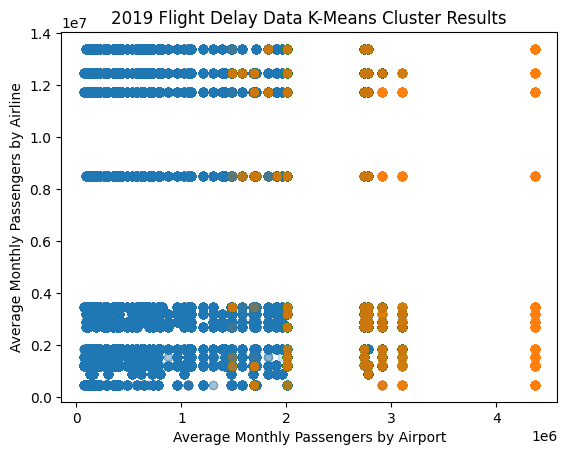

In [34]:
plt.scatter(cluster_0["AVG_MONTHLY_PASS_AIRPORT"], cluster_0["AVG_MONTHLY_PASS_AIRLINE"], alpha=.02)
plt.scatter(cluster_1["AVG_MONTHLY_PASS_AIRPORT"], cluster_1["AVG_MONTHLY_PASS_AIRLINE"], alpha=.02)
plt.xlabel("Average Monthly Passengers by Airport")
plt.ylabel("Average Monthly Passengers by Airline")
plt.title("2019 Flight Delay Data K-Means Cluster Results")
plt.savefig("2019 Flight Delay Data K-Means Cluster Results 2.png")

In [21]:
#Import smallest dataset to be appended to other datasets
#This dataset is measure of a few simple totals that work as a representation of the logistical complexity of each airport
domestic_data_2024 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\T100_Domestic_Market_and_Segment_Data_8942359590531559889.csv")
domestic_data_2024.drop(["year", "enplanements", "arrivals", "OBJECTID"], axis=1, inplace=True) #Redundant with other columns
domestic_data_2024.head()

,origin,passengers,departures,freight,mail
0,01A,17,5,0,0
1,05A,1,1,0,0
2,06A,55,67,139,0
3,09A,43,15,0,0
4,1B1,32,7,0,0


In [22]:
#Import 2015 Flight Delay Data
#Columns 7,8 needed dtype specified directly as infer failed

flights_2015 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2015_Delay_Data\flights.csv", dtype={"DESTINATION_AIRPORT":str, "ORIGIN_AIRPORT":str})

flights_2015.fillna({"AIR_SYSTEM_DELAY":0,"SECURITY_DELAY":0,"AIRLINE_DELAY":0,"LATE_AIRCRAFT_DELAY":0,"WEATHER_DELAY":0}, inplace=True)
flights_2015.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0


In [23]:
#Append airport logistics numbers to the 2015 Flight Delay Dataset
domestic_data_2024.rename({"origin" : "ORIGIN_AIRPORT"}, inplace=True, axis=1)
flight_2015_extended = pd.merge(flights_2015, domestic_data_2024, how='left', on="ORIGIN_AIRPORT")
flight_2015_extended.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,passengers,departures,freight,mail
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,NaN,0.0,0.0,0.0,0.0,0.0,2702278.0,71765.0,3.116064e+09,95095127.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,NaN,0.0,0.0,0.0,0.0,0.0,26340206.0,206637.0,8.440161e+08,47992961.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,NaN,0.0,0.0,0.0,0.0,0.0,17666714.0,138571.0,2.182348e+08,8795256.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,NaN,0.0,0.0,0.0,0.0,0.0,26340206.0,206637.0,8.440161e+08,47992961.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,NaN,0.0,0.0,0.0,0.0,0.0,22288303.0,191107.0,3.490318e+08,14452644.0


In [24]:
#Drop Non-Numeric Columns
flight_2015_delay_vars = flight_2015_extended.drop(["AIRLINE", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CANCELLATION_REASON"], axis=1)
flight_2015_delay_vars.dropna(axis=0, inplace=True)

target = flight_2015_delay_vars["ARRIVAL_DELAY"]
variables = flight_2015_delay_vars.drop("ARRIVAL_DELAY", axis=1)

#Scale features
scaler = StandardScaler()
variables_scl = scaler.fit_transform(variables)

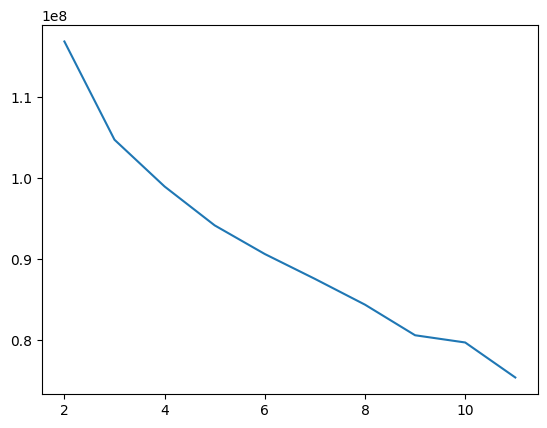

In [71]:
num_clusters = []
inertias = []

for i in range(10):
    best_inertia = 1e15
    for _ in range(10):
        km_model = KMeans(n_clusters=i+2).fit(variables_scl)
        inertia = km_model.inertia_
        if inertia < best_inertia:
            best_inertia = inertia
    inertias.append(best_inertia)
    num_clusters.append(i+2)

plt.plot(num_clusters,inertias)

It looks like the best Elbow point would be 3 or 9.

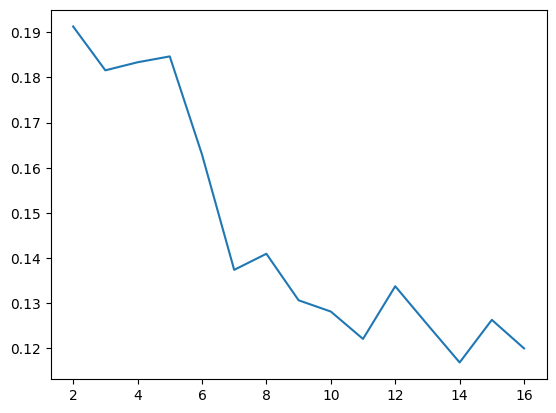

In [72]:
num_clusters = []
silhouettes = []

for i in range(15):
    best_silhouette = 0
    for _ in range(10):
        km_model = KMeans(n_clusters=i+2).fit(variables_scl)
        labels = km_model.labels_
        score = metrics.silhouette_score(variables_scl, labels=labels, sample_size=5000, random_state=42)
        if score > best_silhouette:
            best_silhouette = score
    silhouettes.append(best_silhouette)
    num_clusters.append(i+2)

plt.plot(num_clusters,silhouettes)

Once again by Silhouette score the optimal number of clusters is 2. There is not really a way to see 2 clusters on the Inertia plot when looking for an elbow. That might be why I am having difficulty spotting elbow points.

In [31]:
km_model = KMeans(n_clusters=2, random_state=42).fit(variables_scl)
labels = km_model.labels_
variables['Cluster'] = labels

cluster_0 = variables[variables['Cluster']==0]
cluster_1 = variables[variables['Cluster']==1]
cluster_0.mean() - cluster_1.mean()

YEAR                   0.000000e+00
MONTH                 -8.165747e-02
DAY                   -5.610514e-02
DAY_OF_WEEK           -5.287662e-02
FLIGHT_NUMBER          1.189061e+03
SCHEDULED_DEPARTURE    2.153971e+01
DEPARTURE_TIME         3.099770e+01
DEPARTURE_DELAY       -2.779234e+00
TAXI_OUT              -2.648753e+00
WHEELS_OFF             4.390001e+01
SCHEDULED_TIME        -1.491582e+02
ELAPSED_TIME          -1.473615e+02
AIR_TIME              -1.433376e+02
DISTANCE              -1.211000e+03
WHEELS_ON             -1.179359e+01
TAXI_IN               -1.375127e+00
SCHEDULED_ARRIVAL     -1.592413e+01
ARRIVAL_TIME          -8.477853e+00
DIVERTED               0.000000e+00
CANCELLED              0.000000e+00
AIR_SYSTEM_DELAY      -1.838944e+00
SECURITY_DELAY        -8.954290e-03
AIRLINE_DELAY         -1.164685e+00
LATE_AIRCRAFT_DELAY    6.414795e-01
WEATHER_DELAY         -1.503164e-01
passengers            -2.606085e+06
departures            -2.255257e+04
freight               -1.122

Text(0.5, 1.0, '2015 Flight Delay Data Cluster Results')

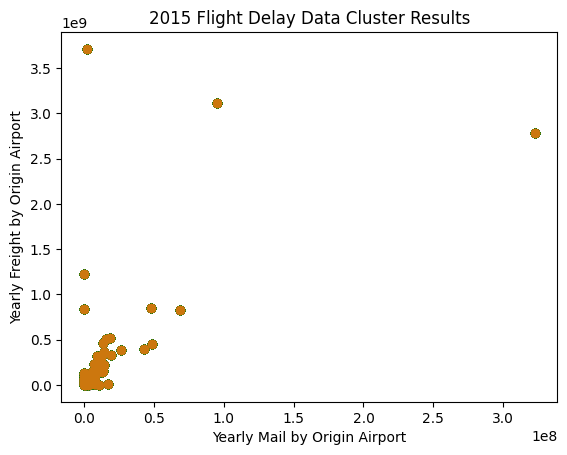

In [12]:
plt.scatter(cluster_0["mail"], cluster_0["freight"], alpha=.02)
plt.scatter(cluster_1["mail"], cluster_1["freight"], alpha=.02)
plt.xlabel("Yearly Mail by Origin Airport")
plt.ylabel("Yearly Freight by Origin Airport")
plt.title("2015 Flight Delay Data Cluster Results")

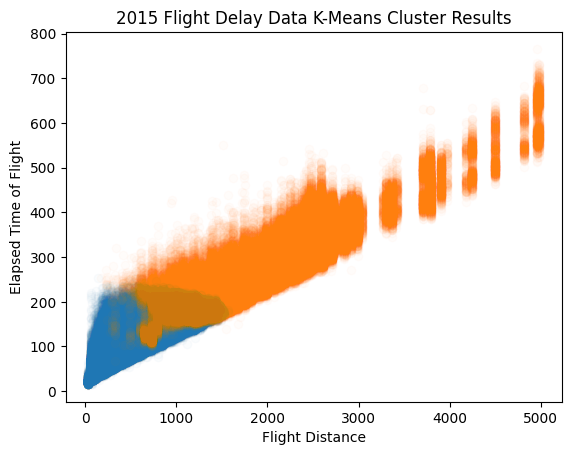

In [32]:
plt.scatter(cluster_0["DISTANCE"], cluster_0["ELAPSED_TIME"], alpha=.02)
plt.scatter(cluster_1["DISTANCE"], cluster_1["ELAPSED_TIME"], alpha=.02)
plt.xlabel("Flight Distance")
plt.ylabel("Elapsed Time of Flight")
plt.title("2015 Flight Delay Data K-Means Cluster Results")
plt.savefig("2015 Flight Delay Data K-Means Cluster Results 2.png")

Text(0.5, 1.0, '2015 Flight Delay Data Cluster Results')

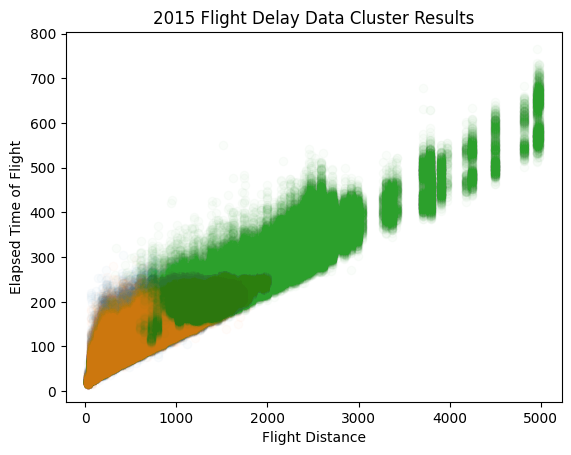

In [82]:
km_model = KMeans(n_clusters=3).fit(variables_scl)
labels = km_model.labels_
variables['Cluster'] = labels

cluster_0 = variables[variables['Cluster']==0]
cluster_1 = variables[variables['Cluster']==1]
cluster_2 = variables[variables['Cluster']==2]

plt.scatter(cluster_0["DISTANCE"], cluster_0["ELAPSED_TIME"], alpha=.02)
plt.scatter(cluster_1["DISTANCE"], cluster_1["ELAPSED_TIME"], alpha=.02)
plt.scatter(cluster_2["DISTANCE"], cluster_2["ELAPSED_TIME"], alpha=.02)
plt.xlabel("Flight Distance")
plt.ylabel("Elapsed Time of Flight")
plt.title("2015 Flight Delay Data Cluster Results")

In [14]:
#Import Delays and Causes Dataset

delay_causes = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\Flight_Delay_and_Causes_Data\Flight_delay.csv")
#Remove the few duplicate datapoints
delay_causes.drop_duplicates(keep="first", inplace=True)
#Drop columns with no information (all values are the same)
delay_causes.drop(["Cancelled","Diverted","CancellationCode"],axis=1, inplace=True)
#Fix long delays to break out of 24 hour time to show the real delay length
data_to_shift = delay_causes[delay_causes["ArrTime"] < (delay_causes["CRSArrTime"] - 100)].index
delay_causes.loc[data_to_shift,"ArrTime"] = delay_causes.loc[data_to_shift,"ArrTime"] + 2400
                           
delay_causes.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,Dest,Dest_Airport,Distance,TaxiIn,TaxiOut,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,BWI,Baltimore-Washington International Airport,515,3,10,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,LAS,McCarran International Airport,1591,3,7,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,MCO,Orlando International Airport,828,6,8,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,PHX,Phoenix Sky Harbor International Airport,1489,7,8,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,TPA,Tampa International Airport,838,4,9,0,0,0,0,16


In [15]:
#Append Logistics Dataset
domestic_data_2024.rename({"ORIGIN_AIRPORT" : "Origin"}, inplace=True, axis=1)
delay_causes_extended = pd.merge(delay_causes, domestic_data_2024, how='left', on="Origin")
delay_causes_extended.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiOut,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,passengers,departures,freight,mail
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,10,2,0,0,0,32,5194000.0,60772.0,842478043.0,84741.0
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,7,10,0,0,0,47,5194000.0,60772.0,842478043.0,84741.0
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,8,8,0,0,0,72,5194000.0,60772.0,842478043.0,84741.0
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,8,3,0,0,0,12,5194000.0,60772.0,842478043.0,84741.0
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,9,0,0,0,0,16,5194000.0,60772.0,842478043.0,84741.0


In [16]:
#Drop non-numeric columns
num_delay_causes = delay_causes_extended.drop(["Date", "UniqueCarrier", "Airline", "TailNum", "Origin", "Org_Airport", "Dest", "Dest_Airport"], axis = 1)
#Drop missing data
num_delay_causes.dropna(axis=0, inplace=True)

target_delay = num_delay_causes["ArrDelay"]
variables_delay = num_delay_causes.drop(["ArrDelay"], axis = 1)

#Scale Data
scaler = StandardScaler()
variables_scl_delay = scaler.fit_transform(variables_delay)

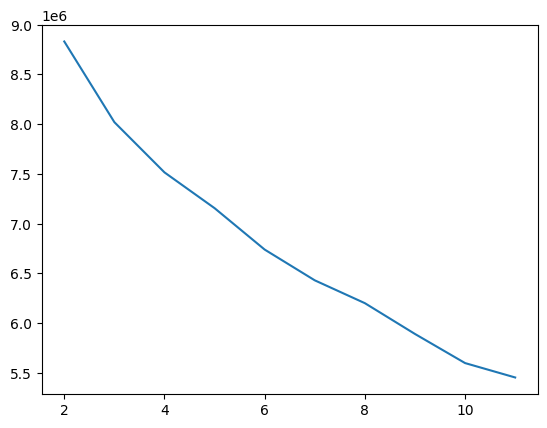

In [81]:
num_clusters = []
inertias = []

for i in range(10):
    best_inertia = 1e15
    for _ in range(10):
        km_model = KMeans(n_clusters=i+2).fit(variables_scl_delay)
        inertia = km_model.inertia_
        if inertia < best_inertia:
            best_inertia = inertia
    inertias.append(best_inertia)
    num_clusters.append(i+2)

plt.plot(num_clusters,inertias)

I once again do not see a clear elbow point. I suspect that means silhouette score will favor 2 clusters again.

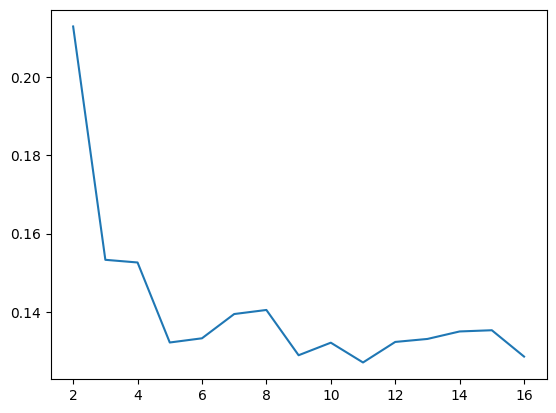

In [83]:
num_clusters = []
silhouettes = []

for i in range(15):
    best_silhouette = 0
    for _ in range(10):
        km_model = KMeans(n_clusters=i+2).fit(variables_scl_delay)
        labels = km_model.labels_
        score = metrics.silhouette_score(variables_scl_delay, labels=labels, sample_size=5000, random_state=42)
        if score > best_silhouette:
            best_silhouette = score
    silhouettes.append(best_silhouette)
    num_clusters.append(i+2)

plt.plot(num_clusters,silhouettes)

In [17]:
km_model = KMeans(n_clusters=2).fit(variables_scl_delay)
labels = km_model.labels_
variables_delay['Cluster'] = labels

cluster_0 = variables_delay[variables_delay['Cluster']==0]
cluster_1 = variables_delay[variables_delay['Cluster']==1]
cluster_0.mean() - cluster_1.mean()

DayOfWeek           -4.091840e-02
DepTime              8.468143e+01
ArrTime             -9.714353e+00
CRSArrTime           3.430819e+00
FlightNum            1.430857e+03
ActualElapsedTime   -1.410588e+02
CRSElapsedTime      -1.351950e+02
AirTime             -1.329676e+02
DepDelay            -1.886439e+00
Distance            -1.079289e+03
TaxiIn              -1.622394e+00
TaxiOut             -6.468793e+00
CarrierDelay        -3.633618e+00
WeatherDelay         9.996726e-01
NASDelay            -8.258617e+00
SecurityDelay       -1.233240e-03
LateAircraftDelay    3.143585e+00
passengers          -3.377992e+06
departures          -2.872028e+04
freight             -6.343328e+07
mail                -3.551819e+06
Cluster             -1.000000e+00
dtype: float64

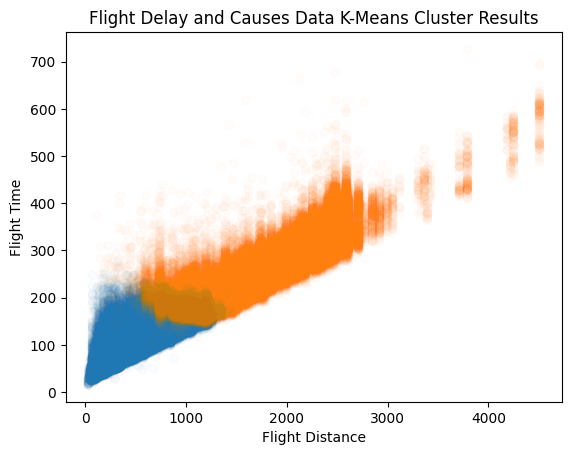

In [19]:
plt.scatter(cluster_0["Distance"], cluster_0["ActualElapsedTime"], alpha=.02)
plt.scatter(cluster_1["Distance"], cluster_1["ActualElapsedTime"], alpha=.02)
plt.xlabel("Flight Distance")
plt.ylabel("Flight Time")
plt.title("Flight Delay and Causes Data K-Means Cluster Results")
plt.savefig("Flight Delay and Causes Data K-Means Cluster Results 2.png")